# Conditional Flow Matching

This notebook is a self-contained example of conditional flow matching. We implement a number of different simulation-free methods for learning flow models. They differ based on the interpolant used and the loss function used to train them.

In this notebook we implement 5 models that can map from a source distribution $q_0$ to a target distribution $q_1$:
* Conditional Flow Matching (CFM)
    * This is equivalent to the basic (non-rectified) formulation of "Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow" [(Liu et al. 2023)](https://openreview.net/forum?id=XVjTT1nw5z)
    * Is similar to "Stochastic Interpolants" [(Albergo et al. 2023)](https://openreview.net/forum?id=li7qeBbCR1t) with a non-variance preserving interpolant.
    * Is similar to "Flow Matching" [(Lipman et al. 2023)](https://openreview.net/forum?id=PqvMRDCJT9t) but conditions on both source and target.
* Optimal Transport CFM (OT-CFM), which directly optimizes for dynamic optimal transport
* Schrödinger Bridge CFM (SB-CFM), which optimizes for Schrödinger Bridge probability paths
* "Building Normalizing Flows with Stochastic Interpolants" [(Albergo et al. 2023)](https://openreview.net/forum?id=li7qeBbCR1t) this corresponds to "VP-CFM" in our README referring to its variance preserving properties.
* "Action Matching: Learning Stochastic Dynamics From Samples" [(Neklyudov et al. 2022)](https://arxiv.org/abs/2210.06662)

Note that this Flow Matching is different from the Generative Flow Network Flow Matching losses. Here we specifically regress against continuous flows, rather than matching inflows and outflows.

In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

import torchcfm.conditional_flow_matching as cfm
import torchcfm.models.models as cfm_models
import torchcfm.utils as cfm_utils

savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)

/Users/noelthomas/Documents/semester-2/ds-lab/scheduled-flow-matching/.venv/lib/python3.13/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


### Conditional Flow Matching

First we implement the basic conditional flow matching. As in the paper, we have
$$
\begin{align}
z &= (x_0, x_1) \\
q(z) &= q(x_0)q(x_1) \\
p_t(x | z) &= \mathcal{N}(x | t * x_1 + (1 - t) * x_0, \sigma^2) \\
u_t(x | z) &= x_1 - x_0
\end{align}
$$
When $\sigma = 0$ this is equivalent to zero-steps of rectified flow. We find that small $\sigma$ helps to regularize the problem ymmv.

In [2]:
# %%time
sigma = 0.1
dim = 2
batch_size = 256
model = cfm_models.MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
FM = cfm.Scheduled(sigma=sigma)
FM = cfm.ConditionalFlowMatcher(sigma=sigma)

start = time.time()
for k in range(5000):
    optimizer.zero_grad()

    x0 = cfm_utils.sample_8gaussians(batch_size)
    x1 = cfm_utils.sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            cfm_utils.torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                cfm_utils.sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            cfm_utils.plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/cfm_v1.pt")

AttributeError: module 'torchcfm.conditional_flow_matching' has no attribute 'Scheduled'

### Optimal Transport Conditional Flow Matching

Next we implement optimal transport conditional flow matching. As in the paper, here we have
$$
\begin{align}
z &= (x_0, x_1) \\
q(z) &= \pi(x_0, x_1) \\
p_t(x | z) &= \mathcal{N}(x | t * x_1 + (1 - t) * x_0, \sigma^2) \\
u_t(x | z) &= x_1 - x_0
\end{align}
$$
where $\pi$ is the joint of an exact optimal transport matrix. We first sample random $x_0, x_1$, then resample according to the optimal transport matrix as computed with the python optimal transport package. We use the 2-Wasserstein distance with an $L^2$ ground distance for equivalence with dynamic optimal transport.

5000: loss 0.163 time 185.04


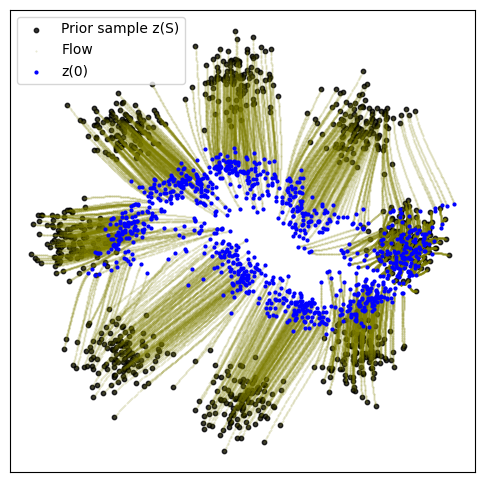

CPU times: user 1h 7min 53s, sys: 12.7 s, total: 1h 8min 6s
Wall time: 3min 7s


In [3]:
%%time
sigma = 0.1
dim = 2
batch_size = 256
model = cfm_models.MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
FM = cfm.ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)

start = time.time()
for k in range(5000):
    optimizer.zero_grad()

    x0 = cfm_utils.sample_8gaussians(batch_size)
    x1 = cfm_utils.sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            cfm_utils.torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                cfm_utils.sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            cfm_utils.plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/otcfm_v1.pt")

#### Plot of the resulting vector field

Here we show a plot of the learned vector field.

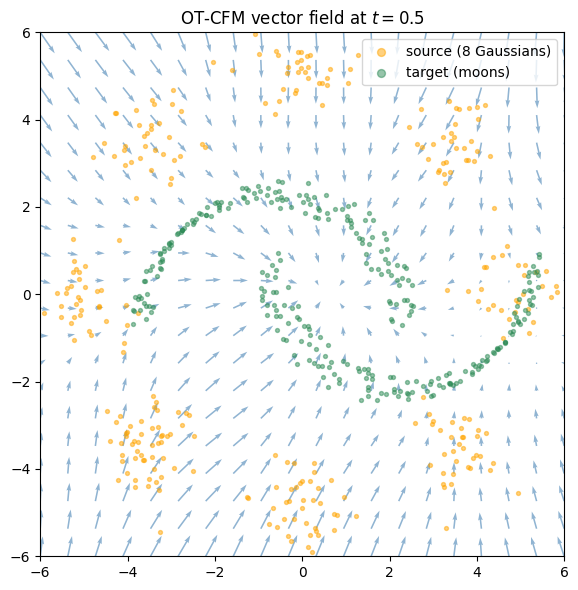

In [4]:

npts = 20
t_val = 0.5

x_range = np.linspace(-6, 6, npts)
y_range = np.linspace(-6, 6, npts)
xx, yy = np.meshgrid(x_range, y_range)
grid = torch.tensor(np.stack([xx.ravel(), yy.ravel()], axis=1), dtype=torch.float32)

with torch.no_grad():
    t_grid = torch.full((grid.shape[0], 1), t_val)
    vf = model(torch.cat([grid, t_grid], dim=-1)).numpy()

x0_samples = cfm_utils.sample_8gaussians(300).numpy()
x1_samples = cfm_utils.sample_moons(300).numpy()

fig, ax = plt.subplots(figsize=(6, 6))
ax.quiver(
    xx, yy,
    vf[:, 0].reshape(npts, npts),
    vf[:, 1].reshape(npts, npts),
    alpha=0.6, color="steelblue",
)
ax.scatter(x0_samples[:, 0], x0_samples[:, 1], s=8, alpha=0.5, color="orange", label="source (8 Gaussians)")
ax.scatter(x1_samples[:, 0], x1_samples[:, 1], s=8, alpha=0.5, color="seagreen", label="target (moons)")
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.set_title(f"OT-CFM vector field at $t = {t_val}$")
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()


### TargetConditionalFlowMatcher (Lipman et al. 2023)

Next we implement the target conditional flow matching from Lipman et al. 2023. Unlike CFM and OT-CFM, this method conditions only on the **target** $x_1$, not on the source-target pair. The probability path contracts from a broad Gaussian at $t=0$ down to a point mass at $x_1$ as $t \to 1$:
$$
\begin{align}
z &= x_1 \\
q(z) &= q(x_1) \\
p_t(x | z) &= \mathcal{N}\!\left(x \,\Big|\, t x_1,\, \bigl(1 - (1 - \sigma_{\min}) t\bigr)^2\right) \\
u_t(x | z) &= \frac{x_1 - (1 - \sigma_{\min})\, x}{1 - (1 - \sigma_{\min})\, t}
\end{align}
$$
With $\sigma_{\min} = 0$ the path collapses exactly to $x_1$ at 

5000: loss 3.103 time 97.43


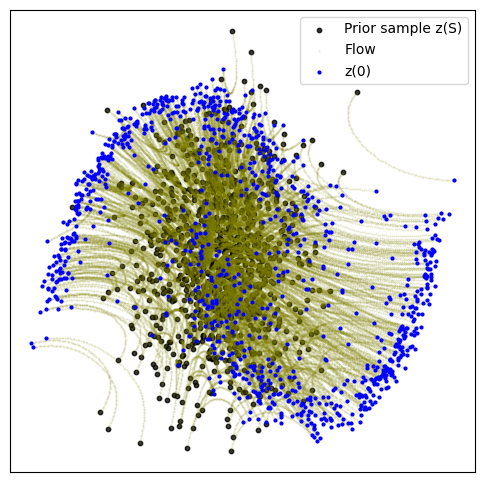

CPU times: user 56min 30s, sys: 8.62 s, total: 56min 39s
Wall time: 1min 40s


In [5]:
%%time
sigma = 1e-3
dim = 2
batch_size = 256
model = cfm_models.MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
FM = cfm.TargetConditionalFlowMatcher(sigma=sigma)

start = time.time()
for k in range(5000):
    optimizer.zero_grad()

    x0 = cfm_utils.sample_8gaussians(batch_size)
    x1 = cfm_utils.sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            cfm_utils.torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                torch.randn(1024, dim),
                t_span=torch.linspace(0, 1, 100),
            )
            cfm_utils.plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/target_cfm_v1.pt")

### Flow Matching on a 1D Gaussian Mixture

This section applies **Conditional Flow Matching (I-CFM)** to a simple 1D problem:

- **Source** $p_0$: standard Gaussian $\mathcal{N}(0, 1)$
- **Target** $p_1$: mixture of two tight Gaussians $\frac{1}{2}\mathcal{N}(-2,\, 0.01) + \frac{1}{2}\mathcal{N}(+2,\, 0.01)$

The low target variance makes the two modes very sharp, which is a clean stress-test for the vector field.

After training we visualise:
1. Source vs target distributions
2. Particle trajectories in the $(t, x)$ plane
3. The learned vector field $v_\theta(t, x)$ as a 2-D heatmap

In [ ]:
STD_TARGET = 0.1   # std of each mode
CENTERS    = [-2.0, 2.0]


def sample_source(n: int) -> torch.Tensor:
    """Standard Gaussian, shape (n, 1)."""
    return torch.randn(n, 1)


def sample_target(n: int) -> torch.Tensor:
    """Equal mixture of N(-2, 0.01) and N(+2, 0.01), shape (n, 1)."""
    component = torch.randint(0, 2, (n,))
    means     = torch.where(component == 0,
                            torch.tensor(CENTERS[0]),
                            torch.tensor(CENTERS[1]))
    return (means + STD_TARGET * torch.randn(n)).unsqueeze(1)


DIM        = 1
SIGMA      = 0.01      # small noise on the probability path
BATCH_SIZE = 512
N_ITER     = 6000
LR         = 1e-3

In [7]:
%%time
model     = cfm_models.MLP(dim=DIM, time_varying=True, w=128)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
FM        = cfm.ConditionalFlowMatcher(sigma=SIGMA)

losses = []
t0 = time.time()

for k in range(N_ITER):
    optimizer.zero_grad()

    x0 = sample_source(BATCH_SIZE)
    x1 = sample_target(BATCH_SIZE)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt   = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if (k + 1) % 2000 == 0:
        print(f"iter {k+1:>6d} | loss {loss.item():.4f} | elapsed {time.time()-t0:.1f}s")

torch.save(model, f"{savedir}/cfm_1d_v1.pt")

iter   2000 | loss 2.1000 | elapsed 44.1s
iter   4000 | loss 1.8761 | elapsed 96.4s
iter   6000 | loss 1.9951 | elapsed 146.4s
iter   8000 | loss 1.9347 | elapsed 197.7s
iter  10000 | loss 2.4658 | elapsed 244.8s
CPU times: user 3h 38min 22s, sys: 2min 6s, total: 3h 40min 29s
Wall time: 4min 4s


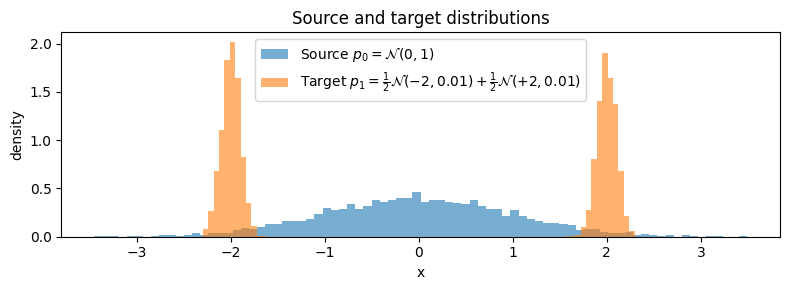

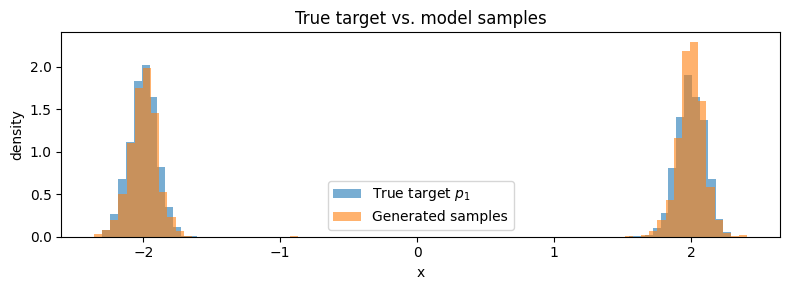

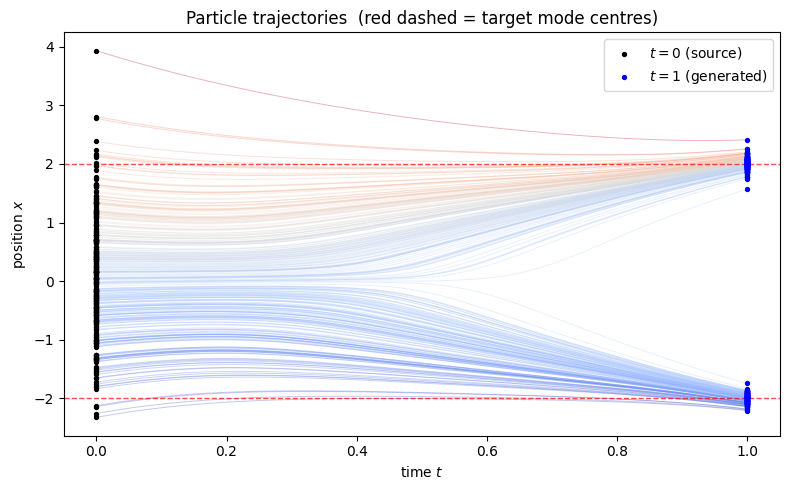

In [8]:
node = NeuralODE(
    cfm_utils.torch_wrapper(model),
    solver="dopri5",
    sensitivity="adjoint",
    atol=1e-5,
    rtol=1e-5,
)

N_SAMPLES = 2000
T_SPAN    = torch.linspace(0, 1, 100)

with torch.no_grad():
    x_init = sample_source(N_SAMPLES)
    traj   = node.trajectory(x_init, t_span=T_SPAN)

traj_np = traj.cpu().numpy()   # (T, N, 1)
t_np    = T_SPAN.numpy()       # (T,)

x_src = sample_source(4000).numpy()
x_tgt = sample_target(4000).numpy()
gen   = traj_np[-1, :, 0]     # final positions

# --- source vs target ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(x_src, bins=80, density=True, alpha=0.6, label=r'Source $p_0 = \mathcal{N}(0,1)$')
ax.hist(x_tgt, bins=80, density=True, alpha=0.6,
        label=r'Target $p_1 = \frac{1}{2}\mathcal{N}(-2,0.01)+\frac{1}{2}\mathcal{N}(+2,0.01)$')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
ax.set_title('Source and target distributions')
plt.tight_layout()
plt.show()

# --- true target vs generated ---
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(x_tgt,        bins=80, density=True, alpha=0.6, label='True target $p_1$')
ax.hist(gen[:, None], bins=80, density=True, alpha=0.6, label='Generated samples')
ax.set_xlabel('x')
ax.set_ylabel('density')
ax.legend()
ax.set_title('True target vs. model samples')
plt.tight_layout()
plt.show()

# --- particle trajectories ---
N_SHOW  = 300
x_start = traj_np[0, :N_SHOW, 0]
vmin, vmax = x_start.min(), x_start.max()

fig, ax = plt.subplots(figsize=(8, 5))
for i in range(N_SHOW):
    c = plt.cm.coolwarm((x_start[i] - vmin) / (vmax - vmin + 1e-8))
    ax.plot(t_np, traj_np[:, i, 0], color=c, alpha=0.3, linewidth=0.7)

ax.scatter(np.zeros(N_SHOW), traj_np[0,  :N_SHOW, 0], s=8, c='black', zorder=3, label='$t=0$ (source)')
ax.scatter(np.ones(N_SHOW),  traj_np[-1, :N_SHOW, 0], s=8, c='blue',  zorder=3, label='$t=1$ (generated)')

for c_val in CENTERS:
    ax.axhline(c_val, color='red', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('time $t$')
ax.set_ylabel('position $x$')
ax.set_title('Particle trajectories  (red dashed = target mode centres)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Scheduled Flow Matching

### TODO: Add more information about scheduling here for context

5000: loss 16.643 time 15.30


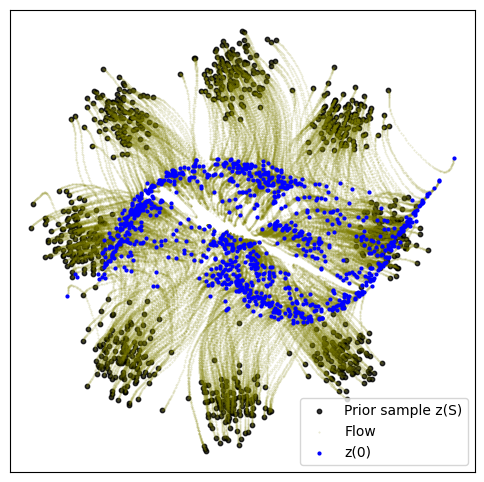

In [ ]:
from torchcfm.schedules import LogisticSchedule
# %%time
sigma = 0.1
dim = 2
batch_size = 256
model = cfm_models.MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
chosen_schedule = LogisticSchedule()
FM = cfm.ScheduledConditionalFlowMatcher(sigma=sigma, schedule=chosen_schedule)

start = time.time()
for k in range(5000):
    optimizer.zero_grad()

    x0 = cfm_utils.sample_8gaussians(batch_size)
    x1 = cfm_utils.sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            cfm_utils.torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                cfm_utils.sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            cfm_utils.plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/scheduled_cfm_logistic.pt")

5000: loss 0.208 time 73.38


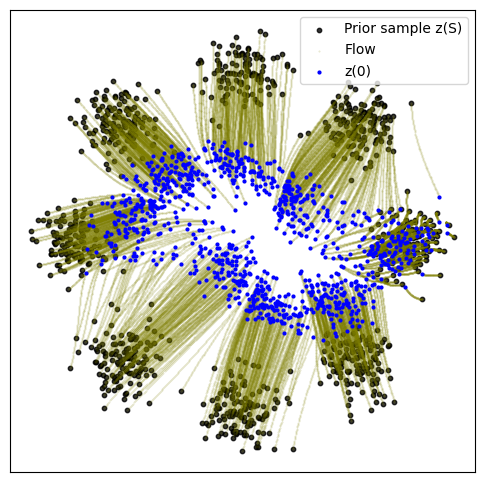

In [6]:
from torchcfm.schedules import LearnableMonotoneSchedule
# %%time
sigma = 0.1
dim = 2
batch_size = 256
model = cfm_models.MLP(dim=dim, time_varying=True)
optimizer = torch.optim.Adam(model.parameters())
chosen_schedule = LearnableMonotoneSchedule()
FM = cfm.ScheduledExactOptimalTransportConditionalFlowMatcher(sigma=sigma, schedule=chosen_schedule)

start = time.time()
for k in range(5000):
    optimizer.zero_grad()

    x0 = cfm_utils.sample_8gaussians(batch_size)
    x1 = cfm_utils.sample_moons(batch_size)

    t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)

    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    loss = torch.mean((vt - ut) ** 2)

    loss.backward()
    optimizer.step()

    if (k + 1) % 5000 == 0:
        end = time.time()
        print(f"{k+1}: loss {loss.item():0.3f} time {(end - start):0.2f}")
        start = end
        node = NeuralODE(
            cfm_utils.torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
        )
        with torch.no_grad():
            traj = node.trajectory(
                cfm_utils.sample_8gaussians(1024),
                t_span=torch.linspace(0, 1, 100),
            )
            cfm_utils.plot_trajectories(traj.cpu().numpy())
torch.save(model, f"{savedir}/scheduled_exact__cfm_logistic.pt")

In [ ]:
torch.wasser